In [15]:
params <- list(
    i_counts_tab="results/ASVs_counts.tsv",
    i_norm_counts_tab="results/ASVs_counts_normalized.tsv",
    i_distances_matrix="results/ASVs_euclidean_distance.tsv",
    i_taxa_table="results/ASVs_taxa.tsv",
    all_meta="resources/metadata/all_meta.csv",
    i_ko="results/picrust2/KO_metagenome_out/pred_metagenome_unstrat.tsv.gz"
)
set.seed(80903)

In [32]:
library(DESeq2)
library(vegan)
library(dplyr)
library(dada2)
library(phyloseq)
source("workflow/scripts/plots/pcoa.R")
source("workflow/scripts/plots/dendrogram.R")


In [17]:
counts_tab <- read.csv(params$i_counts_tab,sep = "\t", row.names='X')

samples_info <- read.csv(params$all_meta, row.names='Run')[colnames(counts_tab), ]
euc_dist_all <- as.dist(as.matrix(read.csv(
    params$i_distances_matrix, 
    sep='\t', 
    header=T,
    row.names=1
)))
taxa_table <- as.matrix(read.csv(params$i_taxa_table, sep = "\t", row.names=1))

samples_info_phy <- sample_data(samples_info)
taxa_table_phy <- tax_table(taxa_table)

phy <- phyloseq(otu_table(counts_tab, taxa_are_rows = T), samples_info_phy, taxa_table_phy)

meta <- data.frame(sample_data(phy))

predictors <- c('depr_or_control', 'batch', 'd_sex', 'd_age_hc')
predictors <- predictors[meta[predictors] |> sapply(function(x) length(unique(x))) > 1]
rhs <- paste(predictors, collapse = " + ")

In [18]:
ko <- read.delim(gzfile(params$i_ko), row.names = 1)
phy_func <- phyloseq(
  otu_table(as.matrix(ko), taxa_are_rows = TRUE),
  sample_data(phy)
)

In [30]:
ko_mat <- t(as(otu_table(phy_func), "matrix"))
ko_dist <- vegan::vegdist(ko_mat, method = "robust.aitchison")

In [44]:
sample_variables(phy)

[1] "ID_KYH"               "hcd_date"             "d_sex"               
 [4] "d_age_hc"             "d_age_hc_grp_10yr"    "d_age_hc_grp_5yr"    
 [7] "b_a9"                 "bd_education3_vs"     "bd_phq9_sev_score"   
[10] "bd_phq9_dep_alt"      "bd_phq9_symptomcount" "bd_phq9_dep_cat"     
[13] "bd_phq9_any_dep"      "bd_phq9_mod_dep"      "b_e1"                
[16] "b_e2"                 "b_e3"                 "b_e4"                
[19] "b_e5"                 "b_e6"                 "b_e7"                
[22] "b_e8"                 "b_e9"                 "b_e10"               
[25] "lab_lc_w8"            "lab_lc_w8b"           "lab_lc_w8a"          
[28] "hc_c1"                "hcd_c2g_g4"           "hcd_c2g5"            
[31] "hcd_c2g_f5"           "hcd_c2g_g5"           "hcd_c2g6"            
[34] "hcd_c2g_f6"           "hcd_c2g_g6"           "hcd_c2g7"            
[37] "hcd_c2g_f7"           "hcd_c2g_g7"           "hcd_c2g1"            
[40] "hcd_c2g_f1"           "hcd_c2g_g1"           "hcd_c2g2"            
[43] "hcd_c2g_f2"           "hcd_c2g_g2"           "hcd_c2g3"            
[46] "hcd_c2g_f3"           "hcd_c2g_g3"           "hcd_c2g4"            
[49] "hcd_c2g_f4"           "atc1"                 "atc2"                
[52] "atc3"                 "atc4"                 "atc5"                
[55] "atc6"                 "atc7"                 "antidepressant_usage"
[58] "antibiotics_usage"    "season"               "depr_or_control"     
[61] "batch"                "new_id"

In [40]:
head(tax_table(phy))

,domain,phylum,class,order,family,genus,species
ASV_1,Bacteria,Bacillota,Clostridia,Lachnospirales,Lachnospiraceae,NA,NA
ASV_2,Bacteria,Bacillota,Clostridia,Lachnospirales,Lachnospiraceae,NA,NA
ASV_3,Bacteria,Bacillota,Clostridia,Lachnospirales,Lachnospiraceae,NA,NA
ASV_4,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,NA
ASV_5,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides,NA
ASV_6,Bacteria,Bacillota,Clostridia,Lachnospirales,Lachnospiraceae,NA,NA


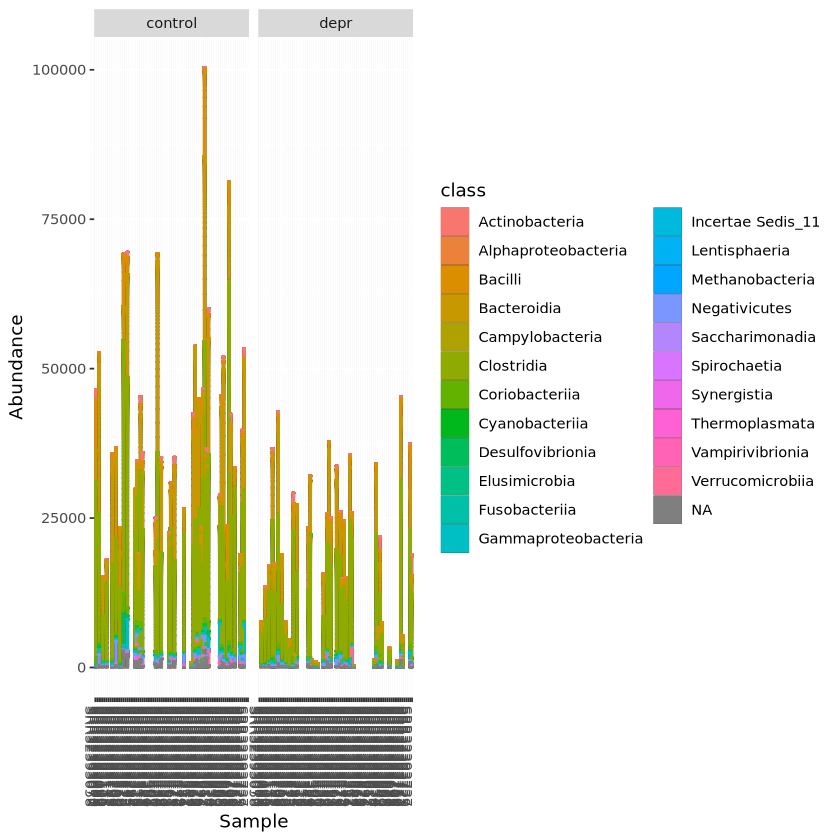

In [47]:
plot_bar(phy, fill="class", facet_grid=~depr_or_control) + geom_bar(aes(color=class, fill=class), stat="identity", position="stack")

In [ ]:
plot_dendrogram(
    ko_dist, phy_func, depr_or_control,
    dist_label = "KO robust Aitchison dist."
)

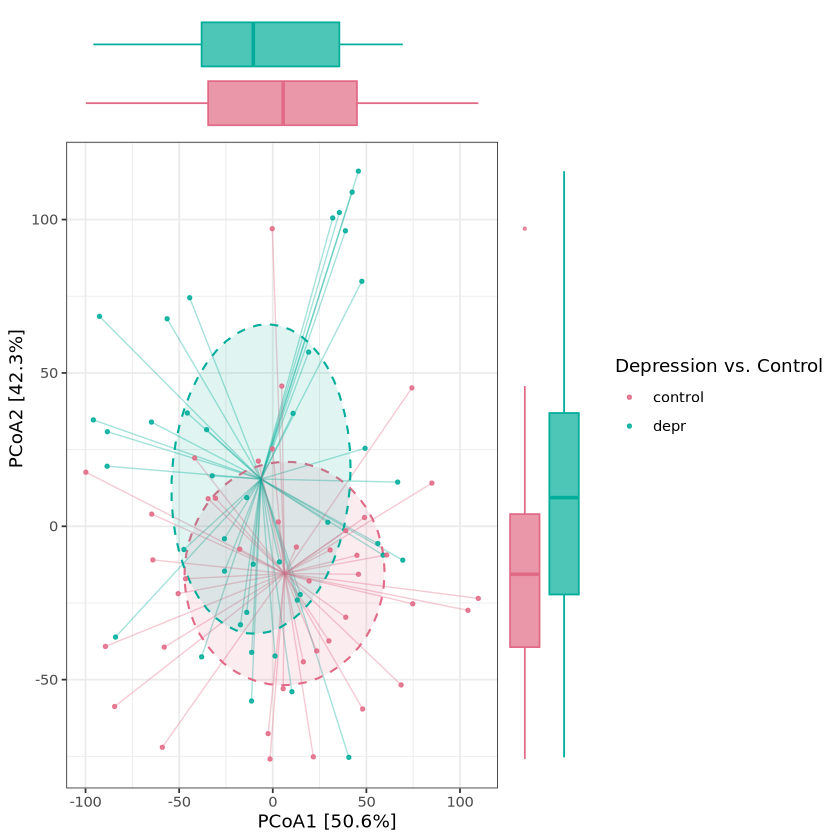

In [31]:
ord_res <- plot_pcoa(phy_func, ko_dist, depr_or_control, legend_title = "Depression vs. Control")
pcoa <- ord_res$pcoa

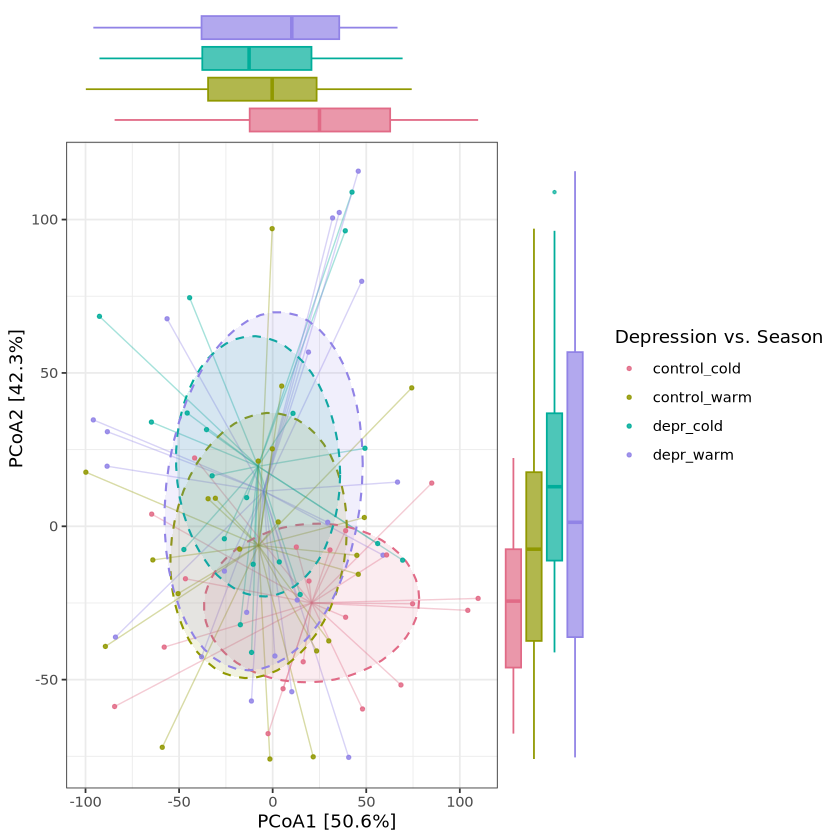

In [28]:
plot_pcoa(phy_func, ko_dist, paste(depr_or_control, season, sep="_"), legend_title="Depression vs. Season")

In [21]:
beta <- betadisper(ko_dist, sample_data(phy_func)$depr_or_control)
anova(beta, by='margin')
beta$group.distances

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,1,533.2162,533.2162,0.6305168,0.429515
Residuals,80,67654.4961,845.6812,NA,NA


control     depr 
60.18197 65.28202

Groups have homogeneous dispersions so i can use premanova without any worries

In [22]:
form_string <- paste("ko_dist", "~", rhs)
f <- as.formula(form_string)
adonis2(f, meta, by = 'margin', permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
depr_or_control,1,20750.682,0.050876951,4.3580230,0.012
batch,1,3643.567,0.008933372,0.7652157,0.496
d_sex,1,1325.072,0.003248838,0.2782893,0.798
d_age_hc,1,11484.675,0.028158364,2.4119919,0.081
Residual,77,366634.706,0.898922574,NA,NA
Total,81,407860.162,1.000000000,NA,NA


In [24]:
paste(sample_data(phy_func)$depr_or_control, sample_data(phy_func)$season, sep="_") |> table()


control_cold control_warm    depr_cold    depr_warm 
          20           21           20           21 

In [25]:
anova(betadisper(
    ko_dist, 
    paste(sample_data(phy_func)$depr_or_control, 
    sample_data(phy_func)$season, sep="_")
), by='margin')

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,3,4005.697,1335.2324,1.50935,0.2186724
Residuals,78,69001.980,884.6408,NA,NA


In [29]:
form_string <- paste("ko_dist", "~", "season * ", rhs)
f <- as.formula(form_string)
adonis2(f, meta, permutations = 999, by = 'margin')

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
batch,1,2081.6404,0.005103809,0.4363140,0.683
d_sex,1,934.0688,0.002290169,0.1957818,0.871
d_age_hc,1,9986.8453,0.024485954,2.0932530,0.126
season:depr_or_control,1,8113.5280,0.019892916,1.7006038,0.160
Residual,75,357822.6786,0.877317061,NA,NA
Total,81,407860.1618,1.000000000,NA,NA
